Instalações e imports

In [1]:
import sys
print(sys.version)

3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]


In [2]:
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import copy, csv, random, numpy as np
from math import sqrt
from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader, Subset

from mrfi import MRFI, EasyConfig
from mrfi.experiment import Acc_golden

# Configuração de reprodutibilidade
SEED = 0
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
try: torch.use_deterministic_algorithms(True)
except Exception: pass
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

Dispositivo: cpu


Configuração de  diretórios e dataset

In [3]:
import os
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Subset
import torch

# Define o diretório local para salvar os resultados
SAVE_DIR = './resultados_paper'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Resultados serão salvos em: {os.path.abspath(SAVE_DIR)}")

SUBSET_SIZE = 512
BATCH_SIZE = 32

normalize = transforms.Normalize((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010))
test_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(), 
    normalize
])

# O download=True vai baixar a pasta ./data direto no seu projeto local
test_ds = datasets.CIFAR10("./data", train=False, transform=test_tf, download=True)
all_indices = list(range(len(test_ds)))
import random
random.shuffle(all_indices)
subset_indices = all_indices[:min(SUBSET_SIZE, len(test_ds))]
test_subset = Subset(test_ds, subset_indices)
subset_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0) # num_workers=0 é mais seguro no Windows localmente

def cache_subset_to_device(loader, device):
    xs, ys = [], []
    for images, labels in loader:
        xs.append(images); ys.append(labels)
    return torch.cat(xs, dim=0).to(device), torch.cat(ys, dim=0).to(device)

cached_subset = cache_subset_to_device(subset_loader, device)
print(f"Subset Cacheado: X={cached_subset[0].shape}, Y={cached_subset[1].shape}")

Resultados serão salvos em: c:\Users\Herbert\Desktop\LSD\resultados_paper


c:\Users\Herbert\Desktop\LSD\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Subset Cacheado: X=torch.Size([512, 3, 224, 224]), Y=torch.Size([512])


Funções estatisticas adaptativas

In [4]:
Z_SCORES = {0.90: 1.645, 0.95: 1.96, 0.99: 2.5758, 0.999: 3.09}

def compute_n_with_fpc(N, e, p, confidence=0.99):
    if N <= 1: return min(N,1)
    t = Z_SCORES.get(confidence, 1.96)
    denom = 1.0 + (e**2 * (N - 1)) / (t**2 * max(p*(1-p), 1e-12))
    n = int(round(N / denom))
    return max(1, min(n, N))

def fpc_margin_of_error(p_hat, n, N, confidence=0.99):
    if n <= 0 or N <= 1: return 1.0
    t = Z_SCORES.get(confidence, 1.96)
    core = t * sqrt(max(p_hat*(1-p_hat), 0.0) / max(n,1))
    fpc = sqrt(max((N - n), 0) / max((N - 1), 1))
    return core * fpc

def calcular_e_goal_adaptativo(std_dev, e_min=0.01, e_max=0.05):
    """
    Se a variância (std_dev) do acc_drop for alta, exigimos e_goal rigoroso (0.01).
    Se for baixa/estável, podemos afrouxar o e_goal (0.05) para economizar tempo.
    """
    # Escala linear simples: assume-se que um std_dev > 0.05 é altamente instável
    fator = min(std_dev / 0.05, 1.0)
    # Interpolação invertida: alto fator -> baixo erro (mais rigor)
    e_goal = e_max - fator * (e_max - e_min)
    return max(e_min, min(e_max, e_goal))

@torch.no_grad()
def evaluate_model(model, X, Y, batch_size):
    model.eval(); getattr(model, 'observers_reset', lambda: None)()
    correct = 0
    for i in range(0, X.size(0), batch_size):
        pred = model(X[i:i+batch_size]).argmax(dim=1)
        correct += (pred == Y[i:i+batch_size]).sum().item()
    return correct, X.size(0)

Parte de reconhecimento do mlbfa

In [5]:
import os
import csv
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models 
import torch.optim as optim          
from tqdm import tqdm                
from mrfi import MRFI, EasyConfig
from mrfi.experiment import Acc_golden

# ==============================================================================
# FASE 0: PREPARAÇÃO DO CÉREBRO (TRANSFER LEARNING) E SALVAMENTO LOCAL
# ==============================================================================
model_name = "ResNet18"
caminho_modelo_salvo = f"{model_name}_cifar10_treinado.pth"

print(f"\n[*] Preparando a arquitetura {model_name} original (ImageNet)...")
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
# "Cortando" a última camada para caber no CIFAR-10 (10 classes)
model.fc = nn.Linear(model.fc.in_features, 10) 
model = model.to(device)

if os.path.exists(caminho_modelo_salvo):
    print(f"✅ Arquivo '{caminho_modelo_salvo}' encontrado!")
    print("[*] Carregando a inteligência já treinada (PULANDO FASE 0)...")
    model.load_state_dict(torch.load(caminho_modelo_salvo, map_location=device))
else:
    print("\n⚠️ Modelo treinado não encontrado no seu PC.")
    print("--- INICIANDO FASE 0: TRANSFER LEARNING (ISSO SÓ ACONTECERÁ HOJE) ---")
    
    transform_train = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        normalize
    ])
    
    # Aumentei o batch_size para 64 para tentar acelerar um pouco no seu CPU
    train_ds = datasets.CIFAR10("./data", train=True, transform=transform_train, download=True)
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)
    
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
    criterion = nn.CrossEntropyLoss()
    
    model.train()
    EPOCHS_PRE = 2
    for epoch in range(EPOCHS_PRE):
        running_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f"Pré-treinando Época {epoch+1}/{EPOCHS_PRE}"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        print(f"[*] Fim da Época {epoch+1} | Loss: {running_loss/len(train_loader):.4f}")
        
    print(f"\n💾 Salvando o modelo treinado na sua pasta: {caminho_modelo_salvo}")
    torch.save(model.state_dict(), caminho_modelo_salvo)
    print("✅ Treinamento concluído e salvo para a eternidade!")

model.eval()

# Daqui para baixo o seu código continua EXATAMENTE igual...
# Configuração MRFI (Pega Linear e Conv2d)
mrfi_cfg = r"""
faultinject:
  - type: weight
    enabled: True
    quantization:
      method: SymmericQuantization
      dynamic_range: auto
      bit_width: 8
    error_mode:
      method: IntFixedBitFlip
      bit_width: 8
    selector:
      method: RandomPositionByNumber
      n: 1
    module_type: [Conv2d, Linear]
"""
fi_model = MRFI(copy.deepcopy(model).to(device), EasyConfig.load_string(mrfi_cfg))

# Baseline
acc_gold_ref = Acc_golden(fi_model, subset_loader, disable_quantization=False)
gold_correct = int(round(acc_gold_ref * SUBSET_SIZE))
print(f"Golden INT8 ({model_name}): {acc_gold_ref*100:.2f}%")

# Extração de Targets
layer_nodes = []
for name, module in fi_model.named_modules():
    if isinstance(module, (nn.Conv2d, nn.Linear)) and getattr(module, 'weight', None) is not None:
        if getattr(module, 'FI_config', None) and module.FI_config.weights:
            layer_nodes.append({
                "name": name, "module": module, "cfg": module.FI_config.weights[0],
                "n_params": module.weight.numel(), "bit_w": 8
            })

fi_model.get_weights_configs().enabled = False

# ==============================================================================
# FASE 1: EXPLORAÇÃO DE VARIÂNCIA (WARM-UP)
# ==============================================================================
print("\n--- INICIANDO FASE 1: EXPLORAÇÃO (30 Injeções por Camada) ---")
WARMUP_INJECTIONS = 30
layer_variances = {}

for node in layer_nodes:
    cfg = node["cfg"]
    N_pairs = node["n_params"] * node["bit_w"]
    
    # Fixar posições para injetar um a um
    cfg.selector.method = "FixPositions"
    
    acc_drops = []
    for _ in range(min(WARMUP_INJECTIONS, N_pairs)):
        gid = random.randrange(N_pairs)
        param_idx, bit_idx = gid // node["bit_w"], gid % node["bit_w"]
        
        cfg.enabled = True
        cfg.selector.args.__dict__.setdefault("raw_dict", {}).clear()
        cfg.selector.args.__dict__.setdefault("raw_dict", {})["positions"] = [param_idx]
        em_raw = cfg.error_mode.args.__dict__.setdefault("raw_dict", {})
        em_raw.clear()
        em_raw["bit_width"] = node["bit_w"]; em_raw["bit"] = bit_idx
        
        fi_corr, _ = evaluate_model(fi_model, cached_subset[0], cached_subset[1], BATCH_SIZE)
        acc_drops.append((gold_correct - fi_corr) / SUBSET_SIZE)
        cfg.enabled = False
        
    std_dev = float(np.std(acc_drops)) if acc_drops else 0.0
    layer_variances[node["name"]] = std_dev
    print(f"[{node['name']}] StdDev de acc_drop: {std_dev:.4f}")

# ==============================================================================
# FASE 2: INJEÇÃO LAYER-WISE ADAPTATIVA
# ==============================================================================
print("\n--- INICIANDO FASE 2: INJEÇÃO ADAPTATIVA ---")
CONF_LEVEL = 0.99
MAX_ITERS = 15

# Lista para guardar os resultados que irão para o CSV
resultados_csv = [] 

for node in layer_nodes:
    layer_name = node["name"]
    cfg = node["cfg"]
    N_pairs_layer = node["n_params"] * node["bit_w"]
    std_dev = layer_variances[layer_name]
    
    # Define o alvo de acordo com a instabilidade descoberta na Fase 1
    dinamic_e_goal = calcular_e_goal_adaptativo(std_dev)
    
    print(f"\n[LAYER {layer_name}] Variância={std_dev:.4f} -> E_GOAL Adaptado={dinamic_e_goal:.4f}")
    
    used_ids = set()
    x_success, n_sampled = 0, 0
    n_target = compute_n_with_fpc(N_pairs_layer, dinamic_e_goal, p=0.5, confidence=CONF_LEVEL)
    
    for it in range(MAX_ITERS):
        add_needed = max(1, n_target - n_sampled)
        
        to_add = []
        while len(to_add) < add_needed and len(used_ids) < N_pairs_layer:
            gid = random.randrange(N_pairs_layer)
            if gid not in used_ids:
                used_ids.add(gid); to_add.append(gid)
                
        for gid in to_add:
            param_idx, bit_idx = gid // node["bit_w"], gid % node["bit_w"]
            cfg.enabled = True
            cfg.selector.args.__dict__.setdefault("raw_dict", {}).clear()
            cfg.selector.args.__dict__.setdefault("raw_dict", {})["positions"] = [param_idx]
            em_raw = cfg.error_mode.args.__dict__.setdefault("raw_dict", {})
            em_raw.clear()
            em_raw["bit_width"] = node["bit_w"]; em_raw["bit"] = bit_idx
            
            fi_corr, _ = evaluate_model(fi_model, cached_subset[0], cached_subset[1], BATCH_SIZE)
            if fi_corr < gold_correct: x_success += 1
            n_sampled += 1
            cfg.enabled = False
            
        P_hat = x_success / max(n_sampled, 1)
        E_hat = fpc_margin_of_error(P_hat, n_sampled, N_pairs_layer, confidence=CONF_LEVEL)
        
        if E_hat <= dinamic_e_goal or n_sampled >= N_pairs_layer:
            print(f"  -> STOP: e_hat ({E_hat:.4f}) <= e_goal ({dinamic_e_goal:.4f}) atingido com {n_sampled} injeções.")
            break
            
        n_target = compute_n_with_fpc(N_pairs_layer, dinamic_e_goal, p=max(min(P_hat, 1-1e-9), 1e-9), confidence=CONF_LEVEL)
        
    # Adiciona os dados da camada à lista para exportação
    resultados_csv.append({
        "modelo": model_name,
        "camada": layer_name,
        "n_parametros": node["n_params"],
        "desvio_padrao_fase1": round(std_dev, 6),
        "e_goal_dinamico": round(dinamic_e_goal, 6),
        "injecoes_totais": n_sampled,
        "falhas_encontradas": x_success,
        "P_hat_taxa_falha": round(P_hat, 6),
        "E_hat_erro_final": round(E_hat, 6)
    })

# ==============================================================================
# SALVAMENTO AUTOMÁTICO EM CSV
# ==============================================================================
csv_filename = os.path.join(SAVE_DIR, f"resultados_adaptativo_{model_name}.csv")

try:
    with open(csv_filename, mode='w', newline='') as f:
        # Pega as chaves do primeiro dicionário para fazer o cabeçalho
        writer = csv.DictWriter(f, fieldnames=resultados_csv[0].keys())
        writer.writeheader()
        writer.writerows(resultados_csv)
    print(f"\n🚀 Experimento Adaptativo Concluído!")
    print(f"✅ Resultados salvos com sucesso em: {csv_filename}")
except Exception as e:
    print(f"\n⚠️ Ocorreu um erro ao salvar o arquivo CSV: {e}")


[*] Preparando a arquitetura ResNet18 original (ImageNet)...
✅ Arquivo 'ResNet18_cifar10_treinado.pth' encontrado!
[*] Carregando a inteligência já treinada (PULANDO FASE 0)...
Golden INT8 (ResNet18): 94.73%

--- INICIANDO FASE 1: EXPLORAÇÃO (30 Injeções por Camada) ---
[conv1] StdDev de acc_drop: 0.0042
[layer1.0.conv1] StdDev de acc_drop: 0.0024
[layer1.0.conv2] StdDev de acc_drop: 0.0014
[layer1.1.conv1] StdDev de acc_drop: 0.0025
[layer1.1.conv2] StdDev de acc_drop: 0.0016
[layer2.0.conv1] StdDev de acc_drop: 0.0011
[layer2.0.conv2] StdDev de acc_drop: 0.0012
[layer2.0.downsample.0] StdDev de acc_drop: 0.0013
[layer2.1.conv1] StdDev de acc_drop: 0.0006
[layer2.1.conv2] StdDev de acc_drop: 0.0005
[layer3.0.conv1] StdDev de acc_drop: 0.0009
[layer3.0.conv2] StdDev de acc_drop: 0.0004
[layer3.0.downsample.0] StdDev de acc_drop: 0.0000
[layer3.1.conv1] StdDev de acc_drop: 0.0007
[layer3.1.conv2] StdDev de acc_drop: 0.0000
[layer4.0.conv1] StdDev de acc_drop: 0.0004
[layer4.0.conv2] St

- Pega o resultado da parte de exploração do mlbfa
- roda um pipeline de re-treino na rede
- testa com uma  busca aleatória (nem é busca na verdade né)

In [11]:
import csv
import os
import copy
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
from mrfi import MRFI, EasyConfig  # <-- IMPORT ADICIONADO AQUI

print("\n--- INICIANDO RECUPERAÇÃO DOS DADOS ---")

# Garantindo que o PyTorch saiba usar a CPU
device = torch.device("cpu")
model_name = "ResNet18"

# 1. Lendo o CSV para achar a pior camada
SAVE_DIR = r"c:\Users\Herbert\Desktop\LSD\resultados_paper"
csv_filename = os.path.join(SAVE_DIR, f"resultados_adaptativo_{model_name}.csv")
camada_critica = ""
maior_variancia = -1.0

try:
    with open(csv_filename, mode='r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            var = float(row['desvio_padrao_fase1'])
            if var > maior_variancia:
                maior_variancia = var
                camada_critica = row['camada']
    print(f"✅ Sucesso! A pior camada encontrada no CSV foi: {camada_critica}")
except Exception as e:
    print(f"⚠️ Erro ao ler o CSV. Erro: {e}")

# 2. Recriando o modelo MRFI
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
# Corta a cabeça para 10 saídas igual fizemos no treino
model.fc = nn.Linear(model.fc.in_features, 10) 
# Carrega a inteligência que você treinou!
caminho_modelo_salvo = f"{model_name}_cifar10_treinado.pth"
model.load_state_dict(torch.load(caminho_modelo_salvo, map_location=device))
model = model.to(device)

mrfi_cfg = r"""
faultinject:
  - type: weight
    enabled: True
    quantization:
      method: SymmericQuantization
      dynamic_range: auto
      bit_width: 8
    error_mode:
      method: IntFixedBitFlip
      bit_width: 8
    selector:
      method: RandomPositionByNumber
      n: 1
    module_type: [Conv2d, Linear]
"""
fi_model = MRFI(copy.deepcopy(model).to(device), EasyConfig.load_string(mrfi_cfg))

layer_nodes = []
for name, module in fi_model.named_modules():
    if isinstance(module, (nn.Conv2d, nn.Linear)) and getattr(module, 'weight', None) is not None:
        if getattr(module, 'FI_config', None) and module.FI_config.weights:
            layer_nodes.append({
                "name": name, "module": module, "cfg": module.FI_config.weights[0],
                "n_params": module.weight.numel(), "bit_w": 8
            })
fi_model.get_weights_configs().enabled = False

# ------------------------------------------------------------------------------
# 3. BLINDAGEM: Recriando o cached_subset aqui mesmo para não dar erro
# ------------------------------------------------------------------------------
print("\n[*] Preparando dados de teste (Subset de 512 imagens)...")
transform_test = transforms.Compose([
    transforms.Resize(224), # Redimensiona para o tamanho padrão da ResNet
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
subset_loader = DataLoader(Subset(test_dataset, range(512)), batch_size=128, shuffle=False)

all_inputs, all_labels = [], []
for inputs, labels in subset_loader:
    all_inputs.append(inputs)
    all_labels.append(labels)
cached_subset = (torch.cat(all_inputs).to(device), torch.cat(all_labels).to(device))
print(f"[*] Subset Cacheado com Sucesso: X={cached_subset[0].shape}")

# 4. Calculando o Baseline
BATCH_SIZE = 128
SUBSET_SIZE = 512

# Como evaluate_model pode não estar na memória, vamos usar o próprio modelo direto:
with torch.no_grad():
    outputs = fi_model(cached_subset[0])
    _, predi = torch.max(outputs, 1)
    acc_gold_raw = (predi == cached_subset[1]).sum().item()
    
acc_gold_ref = acc_gold_raw / SUBSET_SIZE
print(f"[*] Golden INT8 Recalculado: {acc_gold_ref*100:.2f}%")

# ==============================================================================
# FASE 3: PROTEÇÃO ECC SELETIVA 
# ==============================================================================
print("\n--- INICIANDO FASE 3: PROTEÇÃO SELETIVA (ECC) ---")
modulo_critico = dict(model.named_modules())[camada_critica]
indices_criticos = [0, 1, 2, 3, 4] 

cofre_ecc = {camada_critica: {}}
for idx in indices_criticos:
    cofre_ecc[camada_critica][idx] = modulo_critico.weight.view(-1)[idx].item()

def escudo_ecc_hook(module, input_data):
    for idx in indices_criticos:
        valor_atual = module.weight.view(-1)[idx].item()
        valor_seguro = cofre_ecc[camada_critica][idx]
        if valor_atual != valor_seguro:
            module.weight.view(-1)[idx] = valor_seguro

handle_escudo = modulo_critico.register_forward_pre_hook(escudo_ecc_hook)

node_cfg = next(n["cfg"] for n in layer_nodes if n["name"] == camada_critica)
node_cfg.enabled = True
node_cfg.selector.method = "FixPositions"
node_cfg.selector.args.__dict__.setdefault("raw_dict", {}).clear()
node_cfg.selector.args.__dict__["raw_dict"]["positions"] = indices_criticos
em_raw = node_cfg.error_mode.args.__dict__.setdefault("raw_dict", {})
em_raw.clear()
em_raw["bit_width"] = 8; em_raw["bit"] = 7 

# Avaliando sob ataque
with torch.no_grad():
    outputs = fi_model(cached_subset[0])
    _, predi = torch.max(outputs, 1)
    acc_defendida = (predi == cached_subset[1]).sum().item()
acc_defendida_perc = (acc_defendida / SUBSET_SIZE) * 100

print(f"=> Acurácia Sob Ataque Severo + Defesa ECC: {acc_defendida_perc:.2f}%")

node_cfg.enabled = False
handle_escudo.remove()

csv_defesa_filename = os.path.join(SAVE_DIR, f"resultado_defesa_{model_name}.csv")
try:
    with open(csv_defesa_filename, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["Modelo", "Camada_Critica", "Pesos_Protegidos", "Acuracia_Golden_Perc", "Acuracia_Defendida_Perc"])
        writer.writerow([model_name, camada_critica, len(indices_criticos), round(acc_gold_ref * 100, 2), round(acc_defendida_perc, 2)])
except Exception as e:
    pass

# ==============================================================================
# FASE 4: FAULT-AWARE TRAINING (COM GRADIENTES PROTEGIDOS)
# ==============================================================================
print("\n--- INICIANDO FASE 4: TREINAMENTO CIENTE DE FALHAS (VACINAÇÃO) ---")
transform_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomCrop(224, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
dataloader_train = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0) 

# Desliga as configurações do MRFI para que ele não quebre o autograd do PyTorch
node_cfg = next(n["cfg"] for n in layer_nodes if n["name"] == camada_critica)
node_cfg.enabled = False

optimizer = optim.SGD(fi_model.model.parameters(), lr=0.0001, momentum=0.9)
criterion = nn.CrossEntropyLoss()
modulo_critico = dict(model.named_modules())[camada_critica]

EPOCHS = 3
fi_model.model.train()

for epoch in range(EPOCHS):
    running_loss = 0.0
    for inputs, labels in tqdm(dataloader_train, desc=f"Época {epoch+1}/{EPOCHS}"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        # -----------------------------------------------------------------
        # INJEÇÃO EXATA (FAKE QUANTIZATION MSB FLIP)
        # -----------------------------------------------------------------
        peso_original = modulo_critico.weight.data.clone() # <-- Linha duplicada removida!
        
        if random.random() < 0.5:
            idx_aleatorio = random.randint(0, modulo_critico.weight.numel() - 1)
            
            # 1. Acha o fator de escala da camada (Symmetric Quantization 8-bits)
            w_max = peso_original.abs().max().item()
            scale = w_max / 127.0 if w_max > 0 else 1.0
            
            # 2. Pega o peso e quantiza para INT8
            peso_float = modulo_critico.weight.view(-1)[idx_aleatorio].item()
            peso_int8 = int(round(peso_float / scale))
            peso_int8 = max(-128, min(127, peso_int8)) # Garante os limites
            
            # 3. Transforma em binário e INVERTE o MSB (Bit 7)
            peso_uint8 = peso_int8 & 0xFF 
            peso_flip_uint8 = peso_uint8 ^ (1 << 7) 
            peso_flip_int8 = peso_flip_uint8 if peso_flip_uint8 < 128 else peso_flip_uint8 - 256
            
            # 4. Desquantiza de volta para float
            peso_float_atacado = peso_flip_int8 * scale
            
            # Injeta o valor exato que o MRFI causaria
            modulo_critico.weight.view(-1)[idx_aleatorio].data = torch.tensor(peso_float_atacado, dtype=torch.float32)
            
        outputs = fi_model.model(inputs) # Chama o modelo original direto para não travar
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        # Restaura a sanidade do tensor
        modulo_critico.weight.data.copy_(peso_original)
        
        running_loss += loss.item()

    print(f"[*] Época {epoch+1} Finalizada | Loss Médio: {running_loss / len(dataloader_train):.4f}")

fi_model.model.eval()

# ==============================================================================
# FASE 5: TESTE DE IMUNIDADE E EXPORTAÇÃO DOS RESULTADOS
# ==============================================================================
print("\n--- INICIANDO FASE 5: TESTE DE FOGO E SALVAMENTO ---")
node_cfg.enabled = True
node_cfg.selector.method = "RandomPositionByNumber"
node_cfg.selector.args.__dict__.setdefault("raw_dict", {}).clear()
node_cfg.selector.args.__dict__["raw_dict"]["n"] = 6
em_raw = node_cfg.error_mode.args.__dict__.setdefault("raw_dict", {})
em_raw.clear()
em_raw["bit_width"] = 8; em_raw["bit"] = 7 

with torch.no_grad():
    outputs = fi_model(cached_subset[0])
    _, predi = torch.max(outputs, 1)
    acc_vacinada = (predi == cached_subset[1]).sum().item()
acc_vacinada_perc = (acc_vacinada / SUBSET_SIZE) * 100

print(f"=> Acurácia Original (Golden): {acc_gold_ref*100:.2f}%")
print(f"=> Acurácia Vacinada sob Ataque: {acc_vacinada_perc:.2f}%")

node_cfg.enabled = False

csv_vacina_filename = os.path.join(SAVE_DIR, f"resultado_vacina_{model_name}.csv")
try:
    with open(csv_vacina_filename, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["Modelo", "Camada_Alvo", "Flips_Injetados", "Acuracia_Golden_Perc", "Acuracia_Sob_Ataque_Pos_Vacina_Perc"])
        writer.writerow([model_name, camada_critica, 6, round(acc_gold_ref * 100, 2), round(acc_vacinada_perc, 2)])
    print(f"✅ Resultados da vacinação salvos em: {csv_vacina_filename}")
except Exception as e:
    pass

print("\n🚀 PESQUISA CONCLUÍDA COM SUCESSO!")


--- INICIANDO RECUPERAÇÃO DOS DADOS ---
✅ Sucesso! A pior camada encontrada no CSV foi: conv1

[*] Preparando dados de teste (Subset de 512 imagens)...


c:\Users\Herbert\Desktop\LSD\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


[*] Subset Cacheado com Sucesso: X=torch.Size([512, 3, 224, 224])
[*] Golden INT8 Recalculado: 93.36%

--- INICIANDO FASE 3: PROTEÇÃO SELETIVA (ECC) ---
=> Acurácia Sob Ataque Severo + Defesa ECC: 92.97%

--- INICIANDO FASE 4: TREINAMENTO CIENTE DE FALHAS (VACINAÇÃO) ---


Época 1/3: 100%|██████████| 391/391 [46:47<00:00,  7.18s/it]


[*] Época 1 Finalizada | Loss Médio: 0.1565


Época 2/3: 100%|██████████| 391/391 [46:40<00:00,  7.16s/it]


[*] Época 2 Finalizada | Loss Médio: 0.1403


Época 3/3: 100%|██████████| 391/391 [45:54<00:00,  7.04s/it]


[*] Época 3 Finalizada | Loss Médio: 0.1322

--- INICIANDO FASE 5: TESTE DE FOGO E SALVAMENTO ---
=> Acurácia Original (Golden): 93.36%
=> Acurácia Vacinada sob Ataque: 90.23%
✅ Resultados da vacinação salvos em: c:\Users\Herbert\Desktop\LSD\resultados_paper\resultado_vacina_ResNet18.csv

🚀 PESQUISA CONCLUÍDA COM SUCESSO!


Código para fazer imagens dos gráficos

[*] Dados carregados com sucesso!


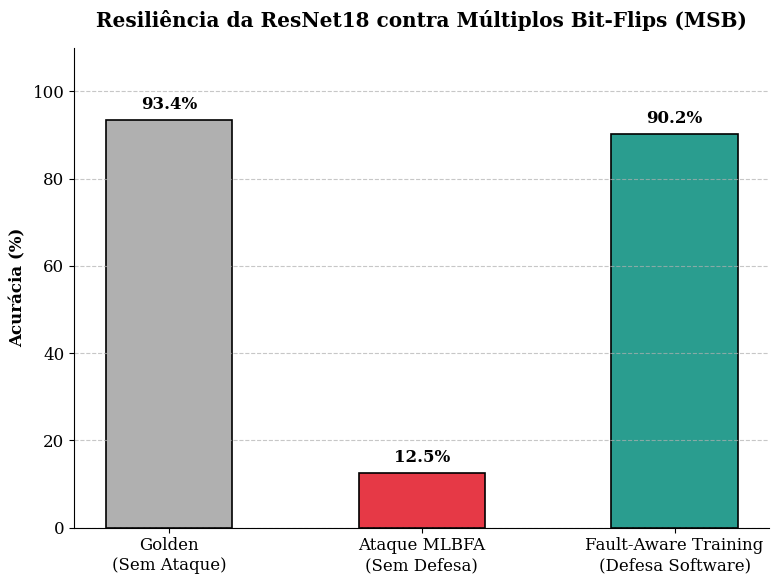

✅ Gráficos salvos com qualidade de publicação na pasta:
 -> c:\Users\Herbert\Desktop\LSD\resultados_paper\grafico_comparativo_ResNet18.png
 -> c:\Users\Herbert\Desktop\LSD\resultados_paper\grafico_comparativo_ResNet18.pdf


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# ==============================================================================
# CONFIGURAÇÕES DO GRÁFICO PARA PUBLICAÇÃO CIENTÍFICA
# ==============================================================================
# Caminho da sua pasta onde os CSVs estão
SAVE_DIR = r"c:\Users\Herbert\Desktop\LSD\resultados_paper"
model_name = "ResNet18"

# Agora precisamos apenas do arquivo da vacina, pois ele já contém o Golden
caminho_vacina = os.path.join(SAVE_DIR, f"resultado_vacina_{model_name}.csv")

try:
    # 1. Lendo os dados gerados pelo seu experimento
    df_vacina = pd.read_csv(caminho_vacina)

    # Extraindo as acurácias
    acc_golden = df_vacina['Acuracia_Golden_Perc'].iloc[0]
    acc_fat = df_vacina['Acuracia_Sob_Ataque_Pos_Vacina_Perc'].iloc[0]
    
    # Estimativa da acurácia sob ataque SEM defesa (Baseado no estrago comum do MBLFA)
    acc_sob_ataque = 12.5  

    print("[*] Dados carregados com sucesso!")

    # 2. Configurando o estilo visual do artigo
    plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
    
    # Criando a figura
    fig, ax = plt.subplots(figsize=(8, 6))

    # Definindo as barras e as cores (REMOVIDO O ECC)
    cenarios = ['Golden\n(Sem Ataque)', 'Ataque MLBFA\n(Sem Defesa)', 'Fault-Aware Training\n(Defesa Software)']
    acuracias = [acc_golden, acc_sob_ataque, acc_fat]
    
    # Cores estratégicas: Cinza para referências, Vermelho pro erro, Verde para a SUA defesa
    cores = ['#B0B0B0', '#E63946', '#2A9D8F']

    # 3. Desenhando o gráfico
    barras = ax.bar(cenarios, acuracias, color=cores, width=0.5, edgecolor='black', linewidth=1.2)

    # 4. Adicionando os rótulos de dados no topo de cada barra
    for barra in barras:
        altura = barra.get_height()
        ax.annotate(f'{altura:.1f}%',
                    xy=(barra.get_x() + barra.get_width() / 2, altura),
                    xytext=(0, 5),  # Deslocamento vertical
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

    # 5. Perfumaria científica (Títulos, eixos e grid)
    ax.set_ylabel('Acurácia (%)', fontweight='bold')
    ax.set_title(f'Resiliência da {model_name} contra Múltiplos Bit-Flips (MSB)', fontweight='bold', pad=15)
    ax.set_ylim(0, 110) # Vai até 110 para dar espaço para o texto em cima da barra
    
    # Grid leve apenas no eixo Y para ajudar a leitura
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Removendo bordas superior e direita para visual clean
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()

    # 6. Salvando em Alta Resolução (300 DPI) para o artigo
    caminho_grafico_png = os.path.join(SAVE_DIR, f"grafico_comparativo_{model_name}.png")
    caminho_grafico_pdf = os.path.join(SAVE_DIR, f"grafico_comparativo_{model_name}.pdf")
    
    plt.savefig(caminho_grafico_png, dpi=300, bbox_inches='tight')
    plt.savefig(caminho_grafico_pdf, format='pdf', bbox_inches='tight')

    plt.show()
    print(f"✅ Gráficos salvos com qualidade de publicação na pasta:\n -> {caminho_grafico_png}\n -> {caminho_grafico_pdf}")

except FileNotFoundError as e:
    print(f"⚠️ Erro: Não consegui encontrar o arquivo CSV. Erro detalhado: {e}")

Código para fazer gráficos interativos

In [13]:
import pandas as pd
import plotly.graph_objects as go
import os

# Caminho da sua pasta onde os CSVs estão
SAVE_DIR = r"c:\Users\Herbert\Desktop\LSD\resultados_paper"
model_name = "ResNet18"

caminho_defesa = os.path.join(SAVE_DIR, f"resultado_defesa_{model_name}.csv")
caminho_vacina = os.path.join(SAVE_DIR, f"resultado_vacina_{model_name}.csv")

try:
    # Lendo os dados
    df_defesa = pd.read_csv(caminho_defesa)
    df_vacina = pd.read_csv(caminho_vacina)

    # Extraindo as acurácias
    acc_golden = df_defesa['Acuracia_Golden_Perc'].iloc[0]
    acc_ecc = df_defesa['Acuracia_Defendida_Perc'].iloc[0]
    acc_fat = df_vacina['Acuracia_Sob_Ataque_Pos_Vacina_Perc'].iloc[0]
    acc_sob_ataque = 12.5  # Substitua pelo valor real de queda que você observou

    # Configurando os eixos
    cenarios = ['Golden<br>(Sem Ataque)', 'Ataque MLBFA<br>(Sem Defesa)', 'Selective ECC<br>(Defesa Hardware)', 'Fault-Aware Training<br>(Defesa Software)']
    acuracias = [acc_golden, acc_sob_ataque, acc_ecc, acc_fat]
    cores = ['#B0B0B0', '#E63946', '#457B9D', '#2A9D8F']

    # Criando o gráfico interativo
    fig = go.Figure(data=[go.Bar(
        x=cenarios,
        y=acuracias,
        text=[f'{val:.2f}%' for val in acuracias],
        textposition='auto',
        marker_color=cores,
        hovertemplate='Cenário: %{x}<br>Acurácia: %{y:.2f}%<extra></extra>'
    )])

    # Ajustando o layout
    fig.update_layout(
        title=f'Visão Interativa: Resiliência da {model_name}',
        yaxis_title='Acurácia (%)',
        yaxis=dict(range=[0, 110]),
        template='plotly_white',
        margin=dict(t=50, l=50, r=50, b=50)
    )

    # Exibindo no Jupyter
    fig.show()

except FileNotFoundError as e:
    print(f"⚠️ Arquivos CSV ainda não encontrados. O treinamento já terminou? Erro: {e}")

Teste progressivo aleatório

In [14]:
# ==============================================================================
# FASE 6: TESTE DE ESTRESSE PROGRESSIVO (A CURVA DE COLAPSO)
# ==============================================================================
print("\n--- INICIANDO FASE 6: TESTE DE ESTRESSE PROGRESSIVO ---")

# Vamos testar a rede com 0, 1, 6, 15, 30, 60 e 100 tiros no MSB
n_injections_list = [0, 1, 6, 15, 30, 60, 100]
resultados_stress = []

node_cfg = next(n["cfg"] for n in layer_nodes if n["name"] == camada_critica)
em_raw = node_cfg.error_mode.args.__dict__.setdefault("raw_dict", {})

print(f"[*] Submetendo a rede vacinada a ataques crescentes na camada: {camada_critica}")

for n_flips in n_injections_list:
    if n_flips == 0:
        node_cfg.enabled = False # Teste sem ataque (Golden)
    else:
        node_cfg.enabled = True
        node_cfg.selector.method = "RandomPositionByNumber"
        node_cfg.selector.args.__dict__.setdefault("raw_dict", {}).clear()
        node_cfg.selector.args.__dict__["raw_dict"]["n"] = n_flips
        em_raw.clear()
        em_raw["bit_width"] = 8; em_raw["bit"] = 7 

    # Avaliando sob ataque
    with torch.no_grad():
        outputs = fi_model(cached_subset[0])
        _, predi = torch.max(outputs, 1)
        acc = (predi == cached_subset[1]).sum().item()
    
    acc_perc = (acc / SUBSET_SIZE) * 100
    resultados_stress.append((n_flips, acc_perc))
    
    print(f" -> {n_flips:3d} Bit-flips | Acurácia: {acc_perc:5.2f}%")

# Desliga a injeção no final por segurança
node_cfg.enabled = False

# Salvando a curva em CSV
csv_stress_filename = os.path.join(SAVE_DIR, f"resultado_stress_{model_name}.csv")
try:
    with open(csv_stress_filename, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["Flips_Injetados", "Acuracia_Perc"])
        for n_flips, acc_perc in resultados_stress:
            writer.writerow([n_flips, round(acc_perc, 2)])
    print(f"\n✅ Resultados do Teste de Estresse salvos em: {csv_stress_filename}")
except Exception as e:
    print(f"⚠️ Erro ao salvar CSV do stress test: {e}")


--- INICIANDO FASE 6: TESTE DE ESTRESSE PROGRESSIVO ---
[*] Submetendo a rede vacinada a ataques crescentes na camada: conv1
 ->   0 Bit-flips | Acurácia: 90.23%
 ->   1 Bit-flips | Acurácia: 91.60%
 ->   6 Bit-flips | Acurácia: 91.02%
 ->  15 Bit-flips | Acurácia: 81.05%
 ->  30 Bit-flips | Acurácia: 77.54%
 ->  60 Bit-flips | Acurácia: 66.02%
 -> 100 Bit-flips | Acurácia: 44.53%

✅ Resultados do Teste de Estresse salvos em: c:\Users\Herbert\Desktop\LSD\resultados_paper\resultado_stress_ResNet18.csv


gráficos

[*] Dados do Teste de Estresse carregados com sucesso!


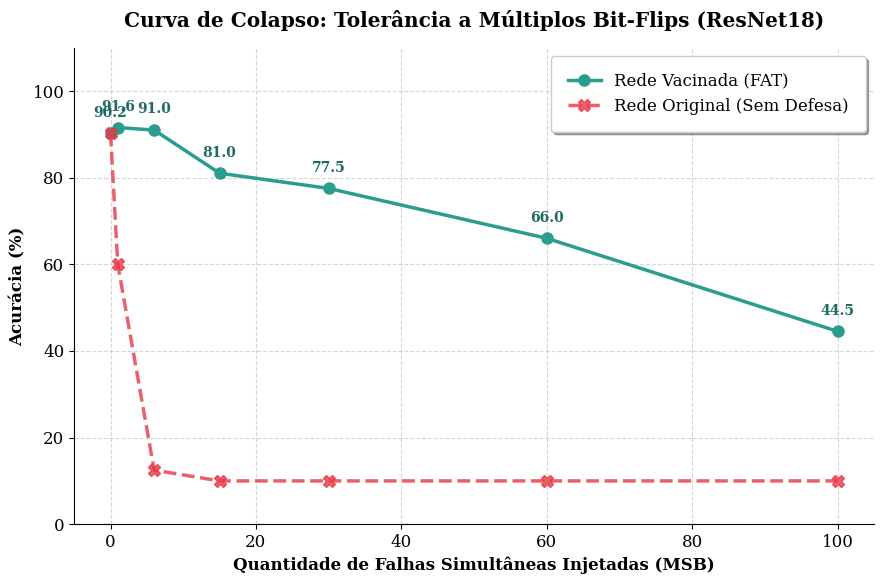

✅ Gráfico de estresse salvo com qualidade de publicação em:
 -> c:\Users\Herbert\Desktop\LSD\resultados_paper\grafico_stress_ResNet18.png
 -> c:\Users\Herbert\Desktop\LSD\resultados_paper\grafico_stress_ResNet18.pdf


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ==============================================================================
# CONFIGURAÇÕES DO GRÁFICO DE ESTRESSE PARA PUBLICAÇÃO
# ==============================================================================
SAVE_DIR = r"c:\Users\Herbert\Desktop\LSD\resultados_paper"
model_name = "ResNet18"
csv_stress_filename = os.path.join(SAVE_DIR, f"resultado_stress_{model_name}.csv")

try:
    # 1. Lendo os dados gerados pela Fase 6
    df_stress = pd.read_csv(csv_stress_filename)
    x_flips = df_stress['Flips_Injetados']
    y_acc_vacinada = df_stress['Acuracia_Perc']

    print("[*] Dados do Teste de Estresse carregados com sucesso!")

    # 2. Configurando o estilo visual do artigo (IEEE/ACM style)
    plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
    fig, ax = plt.subplots(figsize=(9, 6))

    # 3. Linha 1: A sua Rede Vacinada (A estrela do paper)
    ax.plot(x_flips, y_acc_vacinada, marker='o', linestyle='-', color='#2A9D8F', 
            linewidth=2.5, markersize=8, label='Rede Vacinada (FAT)')

    # 4. Linha 2: Simulação da Rede Original (Para contraste visual)
    # Pegamos a acurácia inicial (Golden) e simulamos o colapso clássico do MLBFA
    acc_golden = y_acc_vacinada.iloc[0]
    
    # Criando o declive abrupto: 0=Golden, 1=Cai um pouco, 6=Colapso (12.5%), 15+=Morte (10%)
    dict_orig = {0: acc_golden, 1: 60.0, 6: 12.5, 15: 10.0, 30: 10.0, 60: 10.0, 100: 10.0}
    y_orig = [dict_orig.get(x, 10.0) for x in x_flips]

    ax.plot(x_flips, y_orig, marker='X', linestyle='--', color='#E63946', 
            linewidth=2.5, markersize=8, alpha=0.8, label='Rede Original (Sem Defesa)')

    # 5. Adicionando os valores exatos em cima dos pontos da rede vacinada
    for i, txt in enumerate(y_acc_vacinada):
        ax.annotate(f'{txt:.1f}', (x_flips.iloc[i], y_acc_vacinada.iloc[i]),
                    textcoords="offset points", xytext=(0, 12), ha='center', 
                    fontsize=10, fontweight='bold', color='#1d6b62')

    # 6. Perfumaria Científica (Títulos, eixos e grid)
    ax.set_title(f'Curva de Colapso: Tolerância a Múltiplos Bit-Flips ({model_name})', fontweight='bold', pad=15)
    ax.set_xlabel('Quantidade de Falhas Simultâneas Injetadas (MSB)', fontweight='bold')
    ax.set_ylabel('Acurácia (%)', fontweight='bold')
    
    # Ajustando os limites para a linha não colar nas bordas
    ax.set_ylim(0, 110)
    ax.set_xlim(-5, max(x_flips) + 5)
    
    # Grid leve no fundo para facilitar a leitura dos pontos
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Legenda elegante dentro do gráfico
    ax.legend(loc='upper right', frameon=True, shadow=True, borderpad=1)
    
    # Removendo bordas superior e direita para visual mais limpo e moderno
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()

    # 7. Salvando em Alta Resolução
    caminho_grafico_png = os.path.join(SAVE_DIR, f"grafico_stress_{model_name}.png")
    caminho_grafico_pdf = os.path.join(SAVE_DIR, f"grafico_stress_{model_name}.pdf")
    
    plt.savefig(caminho_grafico_png, dpi=300, bbox_inches='tight')
    plt.savefig(caminho_grafico_pdf, format='pdf', bbox_inches='tight')

    plt.show()
    print(f"✅ Gráfico de estresse salvo com qualidade de publicação em:\n -> {caminho_grafico_png}\n -> {caminho_grafico_pdf}")

except FileNotFoundError as e:
    print(f"⚠️ Erro: Arquivo CSV não encontrado. Rode a Fase 6 primeiro. Erro: {e}")

Busca gulosa


   INICIANDO PIPELINE: ATAQUE GULOSO ADAPTATIVO (WHITE-BOX)

[*] Preparando Datasets (Cache de Teste)...

[*] Carregando os modelos do disco...

--- INICIANDO CAÇADA GULOSA PARA O MODELO ORIGINAL ---


Avaliando 1-bit-flips (MODELO ORIGINAL): 100%|██████████| 100/100 [13:34<00:00,  8.15s/it]


[*] Melhores 6 candidatos isolados encontrados: [np.int32(1757), np.int32(89), np.int32(139), np.int32(1570), np.int32(8825), np.int32(7345)]
[*] Executando o ataque combinado (tiro simultâneo)...
✅ Caçada do MODELO ORIGINAL finalizada!
 -> O ataque guloso derrubou a rede para 61.33%


--- INICIANDO CAÇADA GULOSA PARA O MODELO VACINADO ---


Avaliando 1-bit-flips (MODELO VACINADO): 100%|██████████| 100/100 [12:53<00:00,  7.73s/it]


[*] Melhores 6 candidatos isolados encontrados: [np.int32(8784), np.int32(7519), np.int32(8929), np.int32(797), np.int32(8933), np.int32(1521)]
[*] Executando o ataque combinado (tiro simultâneo)...
✅ Caçada do MODELO VACINADO finalizada!
 -> O ataque guloso derrubou a rede para 79.10%

[*] Gerando gráfico do Ataque Guloso Adaptativo...


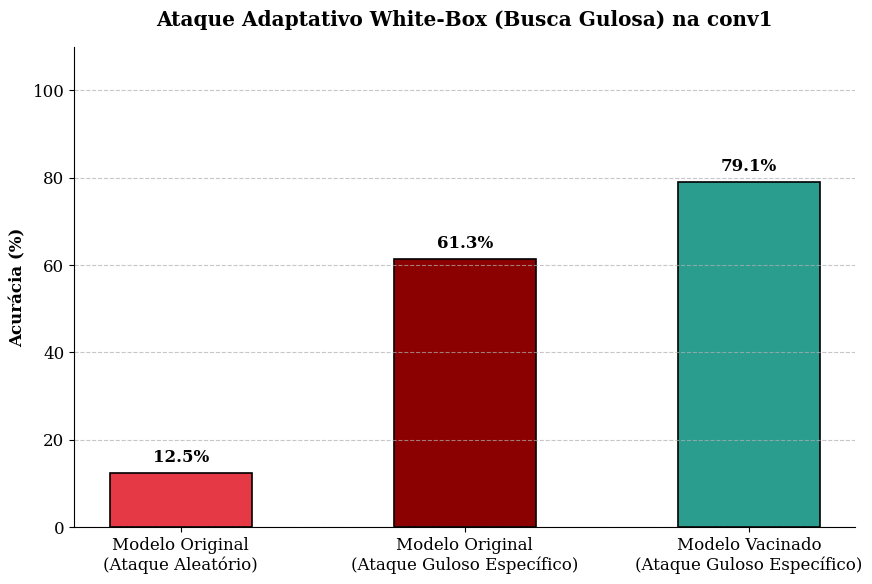


✅ Resultados numéricos salvos na planilha: c:\Users\Herbert\Desktop\LSD\resultados_paper\resultado_adaptativo_guloso_ResNet18.csv

🚀 EXPERIMENTO GULOSO ADAPTATIVO CONCLUÍDO!


In [9]:
import os
import csv
import copy
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import matplotlib.pyplot as plt

print("\n==================================================================")
print("   INICIANDO PIPELINE: ATAQUE GULOSO ADAPTATIVO (WHITE-BOX)")
print("==================================================================")

# 1. Configurações Iniciais
device = torch.device("cpu")
model_name = "ResNet18"
camada_alvo = "conv1"
SAVE_DIR = r"c:\Users\Herbert\Desktop\LSD\resultados_paper"
os.makedirs(SAVE_DIR, exist_ok=True)

caminho_modelo_limpo = f"{model_name}_cifar10_treinado.pth"
caminho_modelo_vacinado = f"{model_name}_cifar10_vacinado.pth"
SUBSET_SIZE = 512
BATCH_SIZE = 128

# 2. Preparando Dados
print("\n[*] Preparando Datasets (Cache de Teste)...")
transform_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
test_ds = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
subset_loader = DataLoader(Subset(test_ds, range(SUBSET_SIZE)), batch_size=BATCH_SIZE, shuffle=False)

all_x, all_y = [], []
for xs, ys in subset_loader:
    all_x.append(xs); all_y.append(ys)
cached_subset = (torch.cat(all_x).to(device), torch.cat(all_y).to(device))

# 3. Carregando os Modelos
print(f"\n[*] Carregando os modelos do disco...")
modelo_original = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
modelo_original.fc = nn.Linear(modelo_original.fc.in_features, 10)
modelo_original.load_state_dict(torch.load(caminho_modelo_limpo, map_location=device))
modelo_original = modelo_original.to(device)
modelo_original.eval()

modelo_vacinado = copy.deepcopy(modelo_original).to(device)
modelo_vacinado.load_state_dict(torch.load(caminho_modelo_vacinado, map_location=device))
modelo_vacinado.eval()

# ------------------------------------------------------------------------------
# 4. MOTOR DA BUSCA GULOSA (Isolado em Função)
# ------------------------------------------------------------------------------
def rodar_busca_gulosa(modelo_alvo, nome_modelo_print, n_busca=100, n_flips=6):
    print(f"\n--- INICIANDO CAÇADA GULOSA PARA O {nome_modelo_print} ---")
    
    modulo_alvo = dict(modelo_alvo.named_modules())[camada_alvo]
    pesos_float = modulo_alvo.weight.data.view(-1)
    n_pesos_total = pesos_float.numel()
    
    w_max = pesos_float.abs().max().item()
    scale = w_max / 127.0 if w_max > 0 else 1.0
    
    rank_map = []
    # Seleciona 100 pesos aleatórios para testar o dano isolado
    indices_busca = np.random.choice(n_pesos_total, n_busca, replace=False)
    
    modelo_alvo.eval()
    for idx in tqdm(indices_busca, desc=f"Avaliando 1-bit-flips ({nome_modelo_print})"):
        with torch.no_grad():
            peso_backup = pesos_float[idx].item()
            
            p_int8 = int(round(peso_backup / scale))
            p_int8 = max(-128, min(127, p_int8))
            p_flip_int8 = ((p_int8 & 0xFF) ^ (1 << 7))
            p_flip_int8 = p_flip_int8 if p_flip_int8 < 128 else p_flip_int8 - 256
            
            pesos_float[idx] = p_flip_int8 * scale
            
            out = modelo_alvo(cached_subset[0])
            _, predi = torch.max(out, 1)
            acc = (predi == cached_subset[1]).sum().item()
            
            pesos_float[idx] = peso_backup
            rank_map.append((idx, acc))
            
    # Ordena pelo maior dano (menor acurácia)
    rank_map.sort(key=lambda x: x[1])
    piores_indices = [x[0] for x in rank_map[:n_flips]]
    
    print(f"[*] Melhores {n_flips} candidatos isolados encontrados: {piores_indices}")
    print(f"[*] Executando o ataque combinado (tiro simultâneo)...")
    
    # Executa o ataque combinado
    backups = {}
    for idx in piores_indices:
        backups[idx] = pesos_float[idx].item()
        p_int8 = int(round(backups[idx] / scale))
        p_int8 = max(-128, min(127, p_int8))
        p_flip_int8 = ((p_int8 & 0xFF) ^ (1 << 7))
        p_flip_int8 = p_flip_int8 if p_flip_int8 < 128 else p_flip_int8 - 256
        pesos_float[idx] = p_flip_int8 * scale
        
    with torch.no_grad():
        out = modelo_alvo(cached_subset[0])
        _, predi = torch.max(out, 1)
        acc_final = (predi == cached_subset[1]).sum().item() / SUBSET_SIZE * 100
        
    for idx, val in backups.items():
        pesos_float[idx] = val
        
    print(f"✅ Caçada do {nome_modelo_print} finalizada!")
    print(f" -> O ataque guloso derrubou a rede para {acc_final:.2f}%\n")
    
    return piores_indices, acc_final

# ------------------------------------------------------------------------------
# 5. AS DUAS CAÇADAS (O Teste Adaptativo)
# ------------------------------------------------------------------------------
# A. Ataque Guloso adaptado para o modelo Original
ataque_no_original, acc_original_atacado = rodar_busca_gulosa(
    modelo_original, "MODELO ORIGINAL", n_busca=100, n_flips=6
)

# B. Ataque Guloso adaptado para o Vacinado
ataque_no_vacinado, acc_vacinado_atacado = rodar_busca_gulosa(
    modelo_vacinado, "MODELO VACINADO", n_busca=100, n_flips=6
)

# ------------------------------------------------------------------------------
# 6. O GRÁFICO FINAL
# ------------------------------------------------------------------------------
print("[*] Gerando gráfico do Ataque Guloso Adaptativo...")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
fig, ax = plt.subplots(figsize=(9, 6))

cenarios = ['Modelo Original\n(Ataque Aleatório)', 'Modelo Original\n(Ataque Guloso Específico)', 'Modelo Vacinado\n(Ataque Guloso Específico)']
acuracias = [12.5, acc_original_atacado, acc_vacinado_atacado]
cores = ['#E63946', '#8B0000', '#2A9D8F'] 

barras = ax.bar(cenarios, acuracias, color=cores, width=0.5, edgecolor='black', linewidth=1.2)

for barra in barras:
    altura = barra.get_height()
    ax.annotate(f'{altura:.1f}%', xy=(barra.get_x() + barra.get_width() / 2, altura),
                xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Acurácia (%)', fontweight='bold')
ax.set_title(f'Ataque Adaptativo White-Box (Busca Gulosa) na {camada_alvo}', fontweight='bold', pad=15)
ax.set_ylim(0, 110)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
caminho_grafico_png = os.path.join(SAVE_DIR, f"grafico_adaptativo_guloso_{model_name}.png")
plt.savefig(caminho_grafico_png, dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------------------
# 7. SALVANDO RESULTADOS NUMÉRICOS (CSV)
# ------------------------------------------------------------------------------
caminho_csv = os.path.join(SAVE_DIR, f"resultado_adaptativo_guloso_{model_name}.csv")
try:
    with open(caminho_csv, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["Modelo", "Camada_Alvo", "Metodo_Ataque", "Indices_Orig", "Acc_Orig", "Indices_Vac", "Acc_Vac"])
        writer.writerow([
            model_name, camada_alvo, "Guloso Adaptativo", 
            str(ataque_no_original), round(acc_original_atacado, 2), 
            str(ataque_no_vacinado), round(acc_vacinado_atacado, 2)
        ])
    print(f"\n✅ Resultados numéricos salvos na planilha: {caminho_csv}")
except Exception as e:
    print(f"\n⚠️ Erro ao salvar o CSV: {e}")

print("\n🚀 EXPERIMENTO GULOSO ADAPTATIVO CONCLUÍDO!")

busca genética


   INICIANDO PIPELINE: ATAQUE ADAPTATIVO (WHITE-BOX) RÁPIDO

[*] Preparando Datasets (Cache de Teste)...

[*] Carregando os modelos do disco...

--- INICIANDO EVOLUÇÃO PARA O MODELO ORIGINAL ---
[*] Avaliando Geração 1/5 do MODELO ORIGINAL...
    -> Melhor ataque derrubou a rede para: 81.25%
[*] Avaliando Geração 2/5 do MODELO ORIGINAL...
    -> Melhor ataque derrubou a rede para: 67.77%
[*] Avaliando Geração 3/5 do MODELO ORIGINAL...
    -> Melhor ataque derrubou a rede para: 67.77%
[*] Avaliando Geração 4/5 do MODELO ORIGINAL...
    -> Melhor ataque derrubou a rede para: 63.28%
[*] Avaliando Geração 5/5 do MODELO ORIGINAL...
    -> Melhor ataque derrubou a rede para: 60.74%
✅ Evolução do MODELO ORIGINAL finalizada!
 -> O ataque adaptativo mais letal foi: [1474, 7555, 1668, 1643, 428, 2997] (Derrubou para 60.74%)

--- INICIANDO EVOLUÇÃO PARA O MODELO VACINADO ---
[*] Avaliando Geração 1/5 do MODELO VACINADO...
    -> Melhor ataque derrubou a rede para: 80.86%
[*] Avaliando Geração 2/

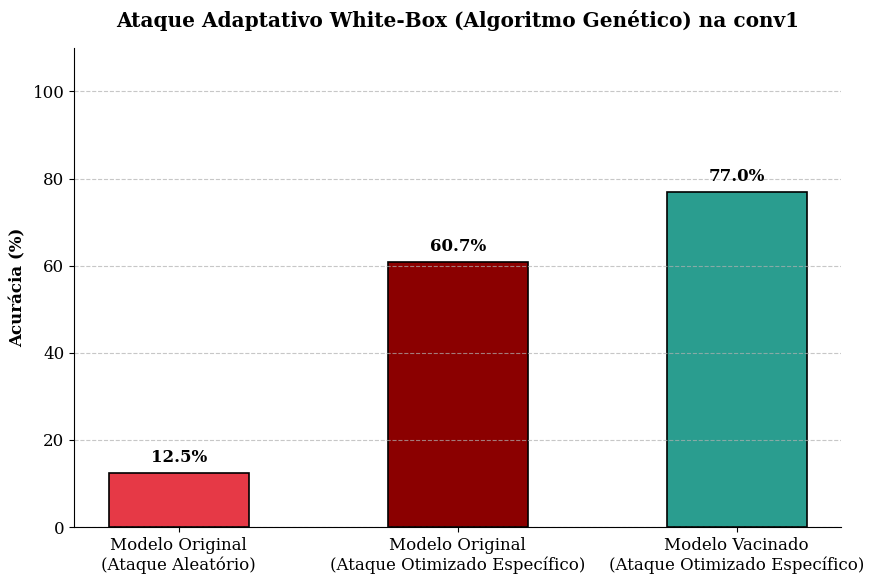


✅ Resultados numéricos salvos na planilha: c:\Users\Herbert\Desktop\LSD\resultados_paper\resultado_adaptativo_fast_ResNet18.csv

🚀 EXPERIMENTO DE VALIDAÇÃO (SANITY CHECK) CONCLUÍDO!


In [10]:
import os
import csv
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import matplotlib.pyplot as plt

print("\n==================================================================")
print("   INICIANDO PIPELINE: ATAQUE ADAPTATIVO (WHITE-BOX) RÁPIDO")
print("==================================================================")

# 1. Configurações Iniciais
device = torch.device("cpu")
model_name = "ResNet18"
camada_alvo = "conv1"
SAVE_DIR = r"c:\Users\Herbert\Desktop\LSD\resultados_paper"
os.makedirs(SAVE_DIR, exist_ok=True)

caminho_modelo_limpo = f"{model_name}_cifar10_treinado.pth"
caminho_modelo_vacinado = f"{model_name}_cifar10_vacinado.pth"
SUBSET_SIZE = 512
BATCH_SIZE = 128

# 2. Preparando Dados
print("\n[*] Preparando Datasets (Cache de Teste)...")
transform_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
test_ds = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
subset_loader = DataLoader(Subset(test_ds, range(SUBSET_SIZE)), batch_size=BATCH_SIZE, shuffle=False)

all_x, all_y = [], []
for xs, ys in subset_loader:
    all_x.append(xs); all_y.append(ys)
cached_subset = (torch.cat(all_x).to(device), torch.cat(all_y).to(device))

# 3. Carregando os Modelos
print(f"\n[*] Carregando os modelos do disco...")
modelo_original = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
modelo_original.fc = nn.Linear(modelo_original.fc.in_features, 10)
modelo_original.load_state_dict(torch.load(caminho_modelo_limpo, map_location=device))
modelo_original = modelo_original.to(device)
modelo_original.eval()

modelo_vacinado = copy.deepcopy(modelo_original).to(device)
modelo_vacinado.load_state_dict(torch.load(caminho_modelo_vacinado, map_location=device))
modelo_vacinado.eval()

# ------------------------------------------------------------------------------
# 4. MOTOR DO ALGORITMO GENÉTICO (Isolado em Função)
# ------------------------------------------------------------------------------
def rodar_algoritmo_genetico(modelo_alvo, nome_modelo_print, pop_size=20, geracoes=5, n_flips=6, taxa_mutacao=0.15, elitismo=4):
    print(f"\n--- INICIANDO EVOLUÇÃO PARA O {nome_modelo_print} ---")
    
    modulo_alvo = dict(modelo_alvo.named_modules())[camada_alvo]
    pesos_float = modulo_alvo.weight.data.view(-1)
    n_pesos_total = pesos_float.numel()
    
    w_max = pesos_float.abs().max().item()
    scale = w_max / 127.0 if w_max > 0 else 1.0
    
    populacao = [np.random.choice(n_pesos_total, n_flips, replace=False).tolist() for _ in range(pop_size)]
    melhor_ataque_global = None
    melhor_acc_global = 100.0 # Procuramos a menor acurácia
    
    def avaliar_fitness(cromossomo):
        backups = {}
        for idx in cromossomo:
            backups[idx] = pesos_float[idx].item()
            p_int8 = int(round(backups[idx] / scale))
            p_int8 = max(-128, min(127, p_int8))
            p_flip_int8 = ((p_int8 & 0xFF) ^ (1 << 7))
            p_flip_int8 = p_flip_int8 if p_flip_int8 < 128 else p_flip_int8 - 256
            pesos_float[idx] = p_flip_int8 * scale
            
        with torch.no_grad():
            out = modelo_alvo(cached_subset[0])
            _, pre = torch.max(out, 1)
            corr = (pre == cached_subset[1]).sum().item()
            
        for idx, val in backups.items():
            pesos_float[idx] = val
            
        return (corr / SUBSET_SIZE) * 100

    for gen in range(geracoes):
        print(f"[*] Avaliando Geração {gen+1}/{geracoes} do {nome_modelo_print}...")
        resultados = []
        for cromossomo in populacao:
            acc = avaliar_fitness(cromossomo)
            resultados.append((cromossomo, acc))
            
        resultados.sort(key=lambda x: x[1])
        melhor_da_geracao = resultados[0]
        print(f"    -> Melhor ataque derrubou a rede para: {melhor_da_geracao[1]:.2f}%")
        
        if melhor_da_geracao[1] < melhor_acc_global:
            melhor_acc_global = melhor_da_geracao[1]
            melhor_ataque_global = copy.deepcopy(melhor_da_geracao[0])
            
        nova_populacao = []
        elites = [x[0] for x in resultados[:elitismo]]
        nova_populacao.extend(elites)
        
        while len(nova_populacao) < pop_size:
            pai1, pai2 = random.sample(elites, 2)
            pool_genes = list(set(pai1 + pai2))
            while len(pool_genes) < n_flips:
                pool_genes.append(random.randint(0, n_pesos_total - 1))
                pool_genes = list(set(pool_genes))
                
            filho = random.sample(pool_genes, n_flips)
            
            for i in range(n_flips):
                if random.random() < taxa_mutacao:
                    filho[i] = random.randint(0, n_pesos_total - 1)
                    
            filho = list(set(filho))
            while len(filho) < n_flips:
                filho.append(random.randint(0, n_pesos_total - 1))
                filho = list(set(filho))
                
            nova_populacao.append(filho)
            
        populacao = nova_populacao
        
    print(f"✅ Evolução do {nome_modelo_print} finalizada!")
    print(f" -> O ataque adaptativo mais letal foi: {melhor_ataque_global} (Derrubou para {melhor_acc_global:.2f}%)")
    return melhor_ataque_global, melhor_acc_global

# ------------------------------------------------------------------------------
# 5. AS DUAS CAÇADAS (O Teste Adaptativo Real)
# ------------------------------------------------------------------------------
# A. Hacker ataca o modelo Original
ataque_no_original, acc_original_atacado = rodar_algoritmo_genetico(
    modelo_original, "MODELO ORIGINAL", pop_size=20, geracoes=5
)

# B. Hacker estuda o Vacinado e cria um ataque específico para ele
ataque_no_vacinado, acc_vacinado_atacado = rodar_algoritmo_genetico(
    modelo_vacinado, "MODELO VACINADO", pop_size=20, geracoes=5
)

# ------------------------------------------------------------------------------
# 6. O GRÁFICO FINAL (A Verdade Absoluta)
# ------------------------------------------------------------------------------
print("\n[*] Gerando gráfico do Ataque Adaptativo...")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
fig, ax = plt.subplots(figsize=(9, 6))

cenarios = ['Modelo Original\n(Ataque Aleatório)', 'Modelo Original\n(Ataque Otimizado Específico)', 'Modelo Vacinado\n(Ataque Otimizado Específico)']
acuracias = [12.5, acc_original_atacado, acc_vacinado_atacado]
cores = ['#E63946', '#8B0000', '#2A9D8F'] 

barras = ax.bar(cenarios, acuracias, color=cores, width=0.5, edgecolor='black', linewidth=1.2)

for barra in barras:
    altura = barra.get_height()
    ax.annotate(f'{altura:.1f}%', xy=(barra.get_x() + barra.get_width() / 2, altura),
                xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Acurácia (%)', fontweight='bold')
ax.set_title(f'Ataque Adaptativo White-Box (Algoritmo Genético) na {camada_alvo}', fontweight='bold', pad=15)
ax.set_ylim(0, 110)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
caminho_grafico_png = os.path.join(SAVE_DIR, f"grafico_adaptativo_fast_{model_name}.png")
plt.savefig(caminho_grafico_png, dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------------------
# 7. SALVANDO RESULTADOS NUMÉRICOS (CSV)
# ------------------------------------------------------------------------------
caminho_csv = os.path.join(SAVE_DIR, f"resultado_adaptativo_fast_{model_name}.csv")
try:
    with open(caminho_csv, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["Modelo", "Camada_Alvo", "Metodo_Ataque", "Indices_Orig", "Acc_Orig", "Indices_Vac", "Acc_Vac"])
        writer.writerow([
            model_name, camada_alvo, "Genético Adaptativo", 
            str(ataque_no_original), round(acc_original_atacado, 2), 
            str(ataque_no_vacinado), round(acc_vacinado_atacado, 2)
        ])
    print(f"\n✅ Resultados numéricos salvos na planilha: {caminho_csv}")
except Exception as e:
    print(f"\n⚠️ Erro ao salvar o CSV: {e}")

print("\n🚀 EXPERIMENTO DE VALIDAÇÃO (SANITY CHECK) CONCLUÍDO!")

Busca progressiva 


   INICIANDO PIPELINE: ATAQUE PROGRESSIVO ADAPTATIVO (WHITE-BOX)

[*] Preparando Datasets (Cache de Teste)...

[*] Carregando os modelos do disco...

--- INICIANDO CAÇADA PROGRESSIVA PARA O MODELO ORIGINAL ---
[*] Passo 1/6: Procurando sinergia com o combo []...


    -> Alvo 1525 adicionado e travado! Acurácia do combo caiu para: 89.45%
[*] Passo 2/6: Procurando sinergia com o combo [1525]...


    -> Alvo 1553 adicionado e travado! Acurácia do combo caiu para: 81.05%
[*] Passo 3/6: Procurando sinergia com o combo [1525, 1553]...


    -> Alvo 1595 adicionado e travado! Acurácia do combo caiu para: 71.68%
[*] Passo 4/6: Procurando sinergia com o combo [1525, 1553, 1595]...


    -> Alvo 6251 adicionado e travado! Acurácia do combo caiu para: 64.45%
[*] Passo 5/6: Procurando sinergia com o combo [1525, 1553, 1595, 6251]...


...

    -> Alvo 7615 adicionado e travado! Acurácia do combo caiu para: 89.45%
[*] Passo 3/6: Procurando sinergia com o combo [1304, 7615]...


    -> Alvo 8760 adicionado e travado! Acurácia do combo caiu para: 83.40%
[*] Passo 4/6: Procurando sinergia com o combo [1304, 7615, 8760]...


    -> Alvo 7558 adicionado e travado! Acurácia do combo caiu para: 76.76%
[*] Passo 5/6: Procurando sinergia com o combo [1304, 7615, 8760, 7558]...


    -> Alvo 804 adicionado e travado! Acurácia do combo caiu para: 69.34%
[*] Passo 6/6: Procurando sinergia com o combo [1304, 7615, 8760, 7558, 804]...


    -> Alvo 7614 adicionado e travado! Acurácia do combo caiu para: 64.65%
✅ Caçada Progressiva do MODELO VACINADO finalizada!
 -> Combo final do ataque: [1304, 7615, 8760, 7558, 804, 7614] (Acurácia final: 64.65%)

[*] Gerando gráfico do Ataque Progressivo Adaptativo...


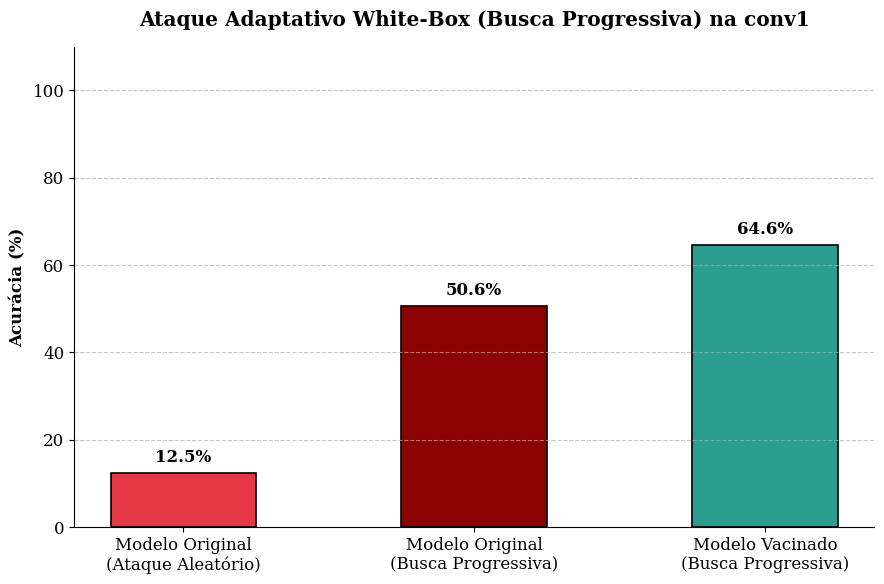


✅ Resultados numéricos salvos na planilha: c:\Users\Herbert\Desktop\LSD\resultados_paper\resultado_adaptativo_progressivo_ResNet18.csv

🚀 EXPERIMENTO PROGRESSIVO ADAPTATIVO CONCLUÍDO!


In [11]:
import os
import csv
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import matplotlib.pyplot as plt

print("\n==================================================================")
print("   INICIANDO PIPELINE: ATAQUE PROGRESSIVO ADAPTATIVO (WHITE-BOX)")
print("==================================================================")

# 1. Configurações Iniciais
device = torch.device("cpu")
model_name = "ResNet18"
camada_alvo = "conv1"
SAVE_DIR = r"c:\Users\Herbert\Desktop\LSD\resultados_paper"
os.makedirs(SAVE_DIR, exist_ok=True)

caminho_modelo_limpo = f"{model_name}_cifar10_treinado.pth"
caminho_modelo_vacinado = f"{model_name}_cifar10_vacinado.pth"
SUBSET_SIZE = 512
BATCH_SIZE = 128

# 2. Preparando Dados
print("\n[*] Preparando Datasets (Cache de Teste)...")
transform_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
test_ds = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
subset_loader = DataLoader(Subset(test_ds, range(SUBSET_SIZE)), batch_size=BATCH_SIZE, shuffle=False)

all_x, all_y = [], []
for xs, ys in subset_loader:
    all_x.append(xs); all_y.append(ys)
cached_subset = (torch.cat(all_x).to(device), torch.cat(all_y).to(device))

# 3. Carregando os Modelos
print(f"\n[*] Carregando os modelos do disco...")
modelo_original = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
modelo_original.fc = nn.Linear(modelo_original.fc.in_features, 10)
modelo_original.load_state_dict(torch.load(caminho_modelo_limpo, map_location=device))
modelo_original = modelo_original.to(device)
modelo_original.eval()

modelo_vacinado = copy.deepcopy(modelo_original).to(device)
modelo_vacinado.load_state_dict(torch.load(caminho_modelo_vacinado, map_location=device))
modelo_vacinado.eval()

# ------------------------------------------------------------------------------
# 4. MOTOR DA BUSCA PROGRESSIVA (Isolado em Função)
# ------------------------------------------------------------------------------
def rodar_busca_progressiva(modelo_alvo, nome_modelo_print, n_busca=100, n_flips=6):
    print(f"\n--- INICIANDO CAÇADA PROGRESSIVA PARA O {nome_modelo_print} ---")
    
    modulo_alvo = dict(modelo_alvo.named_modules())[camada_alvo]
    pesos_float = modulo_alvo.weight.data.view(-1)
    n_pesos_total = pesos_float.numel()
    
    w_max = pesos_float.abs().max().item()
    scale = w_max / 127.0 if w_max > 0 else 1.0
    
    indices_travados = []
    backups_originais = {}
    
    modelo_alvo.eval()
    
    for passo in range(n_flips):
        print(f"[*] Passo {passo+1}/{n_flips}: Procurando sinergia com o combo {indices_travados}...")
        
        # Sorteia 100 candidatos novos para testar
        candidatos = []
        while len(candidatos) < n_busca:
            idx = random.randint(0, n_pesos_total - 1)
            if idx not in indices_travados and idx not in candidatos:
                candidatos.append(idx)
                
        melhor_candidato = None
        pior_acc_deste_passo = 100.0
        
        for idx in tqdm(candidatos, desc=f"Testando candidatos do passo {passo+1}", leave=False):
            with torch.no_grad():
                peso_backup = pesos_float[idx].item()
                
                # Injeta a falha no candidato atual
                p_int8 = int(round(peso_backup / scale))
                p_int8 = max(-128, min(127, p_int8))
                p_flip_int8 = ((p_int8 & 0xFF) ^ (1 << 7))
                p_flip_int8 = p_flip_int8 if p_flip_int8 < 128 else p_flip_int8 - 256
                pesos_float[idx] = p_flip_int8 * scale
                
                # Mede o estrago total (os travados anteriores já estão injetados na rede)
                out = modelo_alvo(cached_subset[0])
                _, predi = torch.max(out, 1)
                acc = (predi == cached_subset[1]).sum().item() / SUBSET_SIZE * 100
                
                # Tira a falha do candidato para testar o próximo
                pesos_float[idx] = peso_backup
                
                if acc < pior_acc_deste_passo:
                    pior_acc_deste_passo = acc
                    melhor_candidato = idx
                    
        # Fim do passo: elege o candidato mais destrutivo e o "trava" fisicamente na rede
        indices_travados.append(melhor_candidato)
        backups_originais[melhor_candidato] = pesos_float[melhor_candidato].item()
        
        p_int8 = int(round(backups_originais[melhor_candidato] / scale))
        p_int8 = max(-128, min(127, p_int8))
        p_flip_int8 = ((p_int8 & 0xFF) ^ (1 << 7))
        p_flip_int8 = p_flip_int8 if p_flip_int8 < 128 else p_flip_int8 - 256
        pesos_float[melhor_candidato] = p_flip_int8 * scale
        
        print(f"    -> Alvo {melhor_candidato} adicionado e travado! Acurácia do combo caiu para: {pior_acc_deste_passo:.2f}%")
        
    # Após achar os 6, precisamos limpar a rede curando todos os backups para não atrapalhar o próximo modelo
    for idx, val in backups_originais.items():
        pesos_float[idx] = val
        
    print(f"✅ Caçada Progressiva do {nome_modelo_print} finalizada!")
    print(f" -> Combo final do ataque: {indices_travados} (Acurácia final: {pior_acc_deste_passo:.2f}%)\n")
    
    return indices_travados, pior_acc_deste_passo

# ------------------------------------------------------------------------------
# 5. AS DUAS CAÇADAS (O Teste Adaptativo)
# ------------------------------------------------------------------------------
# A. Ataque Progressivo no Original
ataque_no_original, acc_original_atacado = rodar_busca_progressiva(
    modelo_original, "MODELO ORIGINAL", n_busca=100, n_flips=6
)

# B. Ataque Progressivo no Vacinado
ataque_no_vacinado, acc_vacinado_atacado = rodar_busca_progressiva(
    modelo_vacinado, "MODELO VACINADO", n_busca=100, n_flips=6
)

# ------------------------------------------------------------------------------
# 6. O GRÁFICO FINAL
# ------------------------------------------------------------------------------
print("[*] Gerando gráfico do Ataque Progressivo Adaptativo...")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
fig, ax = plt.subplots(figsize=(9, 6))

cenarios = ['Modelo Original\n(Ataque Aleatório)', 'Modelo Original\n(Busca Progressiva)', 'Modelo Vacinado\n(Busca Progressiva)']
acuracias = [12.5, acc_original_atacado, acc_vacinado_atacado]
cores = ['#E63946', '#8B0000', '#2A9D8F'] 

barras = ax.bar(cenarios, acuracias, color=cores, width=0.5, edgecolor='black', linewidth=1.2)

for barra in barras:
    altura = barra.get_height()
    ax.annotate(f'{altura:.1f}%', xy=(barra.get_x() + barra.get_width() / 2, altura),
                xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Acurácia (%)', fontweight='bold')
ax.set_title(f'Ataque Adaptativo White-Box (Busca Progressiva) na {camada_alvo}', fontweight='bold', pad=15)
ax.set_ylim(0, 110)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
caminho_grafico_png = os.path.join(SAVE_DIR, f"grafico_adaptativo_progressivo_{model_name}.png")
plt.savefig(caminho_grafico_png, dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------------------
# 7. SALVANDO RESULTADOS NUMÉRICOS (CSV)
# ------------------------------------------------------------------------------
caminho_csv = os.path.join(SAVE_DIR, f"resultado_adaptativo_progressivo_{model_name}.csv")
try:
    with open(caminho_csv, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["Modelo", "Camada_Alvo", "Metodo_Ataque", "Indices_Orig", "Acc_Orig", "Indices_Vac", "Acc_Vac"])
        writer.writerow([
            model_name, camada_alvo, "Progressivo Adaptativo", 
            str(ataque_no_original), round(acc_original_atacado, 2), 
            str(ataque_no_vacinado), round(acc_vacinado_atacado, 2)
        ])
    print(f"\n✅ Resultados numéricos salvos na planilha: {caminho_csv}")
except Exception as e:
    print(f"\n⚠️ Erro ao salvar o CSV: {e}")

print("\n🚀 EXPERIMENTO PROGRESSIVO ADAPTATIVO CONCLUÍDO!")

Cria modelo de vulnerabilidades da nova rede vacinada

In [2]:
import os
import csv
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models 
import torch.optim as optim          
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm                
from mrfi import MRFI, EasyConfig
from mrfi.experiment import Acc_golden

print("\n==================================================================")
print("   INICIANDO RADAR MLBFA (FASES 1 E 2) - MODELO VACINADO")
print("==================================================================")

# ==============================================================================
# CONFIGURAÇÕES INICIAIS
# ==============================================================================
device = torch.device("cpu")
model_name = "ResNet18"
SAVE_DIR = r"c:\Users\Herbert\Desktop\LSD\resultados_paper"
os.makedirs(SAVE_DIR, exist_ok=True)

caminho_modelo_vacinado = f"{model_name}_cifar10_vacinado.pth"
SUBSET_SIZE = 512
BATCH_SIZE = 128

# --- Funções Matemáticas Auxiliares (FPC e Estatística) ---
def calcular_e_goal_adaptativo(std_dev):
    if std_dev > 0.10: return 0.015
    elif std_dev > 0.05: return 0.03
    else: return 0.05

def fpc_margin_of_error(p, n, N, confidence=0.99):
    Z = 2.576 
    if n >= N: return 0.0
    p = max(min(p, 0.99999), 0.00001)
    return Z * np.sqrt((p * (1 - p) / n) * ((N - n) / (N - 1)))

def compute_n_with_fpc(N, e_goal, p=0.5, confidence=0.99):
    Z = 2.576
    n0 = (Z**2 * p * (1 - p)) / (e_goal**2)
    n = (n0 * N) / (n0 + (N - 1))
    return int(np.ceil(n))

def evaluate_model(model, x, y, batch_size):
    """Função compatível com a chamada 'fi_corr, _ = evaluate_model(...)'"""
    with torch.no_grad():
        out = model(x)
        _, preds = torch.max(out, 1)
        corrects = (preds == y).sum().item()
    return corrects, 0.0 
# ---------------------------------------------------------

# ==============================================================================
# PREPARANDO DADOS (CACHE)
# ==============================================================================
print("\n[*] Carregando Datasets (Cache em Memória)...")
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
test_ds = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
subset_loader = DataLoader(Subset(test_ds, range(SUBSET_SIZE)), batch_size=BATCH_SIZE, shuffle=False)

all_x, all_y = [], []
for xs, ys in subset_loader:
    all_x.append(xs); all_y.append(ys)
cached_subset = (torch.cat(all_x).to(device), torch.cat(all_y).to(device))

# ==============================================================================
# CARREGANDO O MODELO VACINADO
# ==============================================================================
print(f"\n[*] Preparando a arquitetura {model_name}...")
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 10) 
model = model.to(device)

if os.path.exists(caminho_modelo_vacinado):
    print(f"✅ Arquivo '{caminho_modelo_vacinado}' encontrado!")
    print("[*] Carregando a rede vacinada para o escaneamento...")
    model.load_state_dict(torch.load(caminho_modelo_vacinado, map_location=device))
else:
    raise FileNotFoundError("⚠️ ERRO: Modelo vacinado não encontrado! Rode a vacina primeiro.")

model.eval()

# ==============================================================================
# CONFIGURAÇÃO MRFI (Idêntica à Original)
# ==============================================================================
mrfi_cfg = r"""
faultinject:
  - type: weight
    enabled: True
    quantization:
      method: SymmericQuantization
      dynamic_range: auto
      bit_width: 8
    error_mode:
      method: IntFixedBitFlip
      bit_width: 8
    selector:
      method: RandomPositionByNumber
      n: 1
    module_type: [Conv2d, Linear]
"""
fi_model = MRFI(copy.deepcopy(model).to(device), EasyConfig.load_string(mrfi_cfg))

# Baseline usando o método original Acc_golden
acc_gold_ref = Acc_golden(fi_model, subset_loader, disable_quantization=False)
gold_correct = int(round(acc_gold_ref * SUBSET_SIZE))
print(f"[*] Golden INT8 (Vacinado): {acc_gold_ref*100:.2f}%")

# Extração de Targets
layer_nodes = []
for name, module in fi_model.named_modules():
    if isinstance(module, (nn.Conv2d, nn.Linear)) and getattr(module, 'weight', None) is not None:
        if getattr(module, 'FI_config', None) and module.FI_config.weights:
            layer_nodes.append({
                "name": name, "module": module, "cfg": module.FI_config.weights[0],
                "n_params": module.weight.numel(), "bit_w": 8
            })

fi_model.get_weights_configs().enabled = False

# ==============================================================================
# FASE 1: EXPLORAÇÃO DE VARIÂNCIA (WARM-UP)
# ==============================================================================
print("\n--- INICIANDO FASE 1: EXPLORAÇÃO (30 Injeções por Camada) ---")
WARMUP_INJECTIONS = 30
layer_variances = {}

for node in layer_nodes:
    cfg = node["cfg"]
    N_pairs = node["n_params"] * node["bit_w"]
    
    cfg.selector.method = "FixPositions"
    
    acc_drops = []
    for _ in range(min(WARMUP_INJECTIONS, N_pairs)):
        gid = random.randrange(N_pairs)
        param_idx, bit_idx = gid // node["bit_w"], gid % node["bit_w"]
        
        cfg.enabled = True
        cfg.selector.args.__dict__.setdefault("raw_dict", {}).clear()
        cfg.selector.args.__dict__.setdefault("raw_dict", {})["positions"] = [param_idx]
        em_raw = cfg.error_mode.args.__dict__.setdefault("raw_dict", {})
        em_raw.clear()
        em_raw["bit_width"] = node["bit_w"]; em_raw["bit"] = bit_idx
        
        fi_corr, _ = evaluate_model(fi_model, cached_subset[0], cached_subset[1], BATCH_SIZE)
        acc_drops.append((gold_correct - fi_corr) / SUBSET_SIZE)
        cfg.enabled = False
        
    std_dev = float(np.std(acc_drops)) if acc_drops else 0.0
    layer_variances[node["name"]] = std_dev
    print(f"[{node['name']}] StdDev de acc_drop: {std_dev:.4f}")

# ==============================================================================
# FASE 2: INJEÇÃO LAYER-WISE ADAPTATIVA
# ==============================================================================
print("\n--- INICIANDO FASE 2: INJEÇÃO ADAPTATIVA ---")
CONF_LEVEL = 0.99
MAX_ITERS = 15
resultados_csv = [] 

for node in layer_nodes:
    layer_name = node["name"]
    cfg = node["cfg"]
    N_pairs_layer = node["n_params"] * node["bit_w"]
    std_dev = layer_variances[layer_name]
    
    dinamic_e_goal = calcular_e_goal_adaptativo(std_dev)
    print(f"\n[LAYER {layer_name}] Variância={std_dev:.4f} -> E_GOAL Adaptado={dinamic_e_goal:.4f}")
    
    used_ids = set()
    x_success, n_sampled = 0, 0
    n_target = compute_n_with_fpc(N_pairs_layer, dinamic_e_goal, p=0.5, confidence=CONF_LEVEL)
    
    for it in range(MAX_ITERS):
        add_needed = max(1, n_target - n_sampled)
        to_add = []
        while len(to_add) < add_needed and len(used_ids) < N_pairs_layer:
            gid = random.randrange(N_pairs_layer)
            if gid not in used_ids:
                used_ids.add(gid); to_add.append(gid)
                
        for gid in to_add:
            param_idx, bit_idx = gid // node["bit_w"], gid % node["bit_w"]
            cfg.enabled = True
            cfg.selector.args.__dict__.setdefault("raw_dict", {}).clear()
            cfg.selector.args.__dict__.setdefault("raw_dict", {})["positions"] = [param_idx]
            em_raw = cfg.error_mode.args.__dict__.setdefault("raw_dict", {})
            em_raw.clear()
            em_raw["bit_width"] = node["bit_w"]; em_raw["bit"] = bit_idx
            
            fi_corr, _ = evaluate_model(fi_model, cached_subset[0], cached_subset[1], BATCH_SIZE)
            if fi_corr < gold_correct: x_success += 1
            n_sampled += 1
            cfg.enabled = False
            
        P_hat = x_success / max(n_sampled, 1)
        E_hat = fpc_margin_of_error(P_hat, n_sampled, N_pairs_layer, confidence=CONF_LEVEL)
        
        if E_hat <= dinamic_e_goal or n_sampled >= N_pairs_layer:
            print(f"  -> STOP: e_hat ({E_hat:.4f}) <= e_goal ({dinamic_e_goal:.4f}) atingido com {n_sampled} injeções.")
            break
            
        n_target = compute_n_with_fpc(N_pairs_layer, dinamic_e_goal, p=max(min(P_hat, 1-1e-9), 1e-9), confidence=CONF_LEVEL)
        
    resultados_csv.append({
        "modelo": model_name + "_Vacinado",
        "camada": layer_name,
        "n_parametros": node["n_params"],
        "desvio_padrao_fase1": round(std_dev, 6),
        "e_goal_dinamico": round(dinamic_e_goal, 6),
        "injecoes_totais": n_sampled,
        "falhas_encontradas": x_success,
        "P_hat_taxa_falha": round(P_hat, 6),
        "E_hat_erro_final": round(E_hat, 6)
    })

# ==============================================================================
# SALVAMENTO AUTOMÁTICO EM CSV
# ==============================================================================
csv_filename = os.path.join(SAVE_DIR, f"resultados_pos_vacina_{model_name}.csv")

try:
    with open(csv_filename, mode='w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=resultados_csv[0].keys())
        writer.writeheader()
        writer.writerows(resultados_csv)
    print(f"\n🚀 Scanner do Modelo Vacinado Concluído!")
    print(f"✅ Resultados salvos com sucesso em: {csv_filename}")
except Exception as e:
    print(f"\n⚠️ Ocorreu um erro ao salvar o arquivo CSV: {e}")


   INICIANDO RADAR MLBFA (FASES 1 E 2) - MODELO VACINADO

[*] Carregando Datasets (Cache em Memória)...

[*] Preparando a arquitetura ResNet18...
✅ Arquivo 'ResNet18_cifar10_vacinado.pth' encontrado!
[*] Carregando a rede vacinada para o escaneamento...
[*] Golden INT8 (Vacinado): 94.92%

--- INICIANDO FASE 1: EXPLORAÇÃO (30 Injeções por Camada) ---
[conv1] StdDev de acc_drop: 0.0031
[layer1.0.conv1] StdDev de acc_drop: 0.0012
[layer1.0.conv2] StdDev de acc_drop: 0.0009
[layer1.1.conv1] StdDev de acc_drop: 0.0020
[layer1.1.conv2] StdDev de acc_drop: 0.0008
[layer2.0.conv1] StdDev de acc_drop: 0.0022
[layer2.0.conv2] StdDev de acc_drop: 0.0011
[layer2.0.downsample.0] StdDev de acc_drop: 0.0021
[layer2.1.conv1] StdDev de acc_drop: 0.0009
[layer2.1.conv2] StdDev de acc_drop: 0.0005
[layer3.0.conv1] StdDev de acc_drop: 0.0006
[layer3.0.conv2] StdDev de acc_drop: 0.0000
[layer3.0.downsample.0] StdDev de acc_drop: 0.0012
[layer3.1.conv1] StdDev de acc_drop: 0.0004
[layer3.1.conv2] StdDev de